# Regime-Switching Sequential Sampling Models with `RSSSM`

Cognitive states are rarely static. Over a session a participant may drift between an **attentive** and a **distracted** state, or switch between a **speed-emphasis** and an **accuracy-emphasis** strategy. A *regime-switching sequential sampling model* captures this directly: a latent Markov chain moves the participant between a small number of **regimes**, and within each regime behaviour is governed by a standard SSM (here a drift-diffusion model) whose parameters take regime-specific values.

The low-level tutorial [*Joint Modeling of Latent Cognitive States and Decision Processes*](hmm_ddm_regime_switching.ipynb) builds such a model **by hand** in PyMC — assembling the transition matrix, the per-regime emission densities, the forward-algorithm `pytensor.scan`, the `pm.Potential`, and a separate Forward-Filter Backward-Sample routine. This tutorial does the same science in a few lines with **`hssm.RSSSM`**, the high-level class that packages all of that machinery behind the familiar `HSSM(...)` / `RLSSM(...)` API.

**The model.**

- **Latent regimes:** $s_t \mid s_{t-1} \sim \text{Categorical}(P_{s_{t-1},\,\cdot})$, where $P$ is the $K \times K$ transition matrix and $s_1 \sim \pi_0$.
- **Emissions:** $(rt_t, \text{resp}_t) \mid s_t = k \sim \text{SSM}(\theta_k)$. Here the drift rate $v$ *switches* across regimes while the boundary $a$, start point $z$, and non-decision time $t$ are *shared*.
- **Inference:** the discrete regimes are marginalised out by the forward algorithm, leaving a continuous-parameter model that NUTS can sample. The regimes themselves are recovered *after* sampling.

We use a single participant and $K = 2$ regimes, switching on the drift rate.

## Part 1: Setup
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import hssm

%config InlineBackend.figure_format = "retina"
np.random.seed(0)

## Part 2: Simulate regime-switching data
---

We generate 500 trials from two regimes that differ only in drift rate:

| Regime | Interpretation | Drift $v$ |
|---|---|---|
| 0 | *distracted* (slow, noisy choices) | $0.2$ |
| 1 | *attentive* (fast, accurate choices) | $1.5$ |

The boundary ($a=0.8$), start point ($z=0.5$), and non-decision time ($t=0.3$) are shared. The regime sequence follows a **sticky** Markov chain — switches are rare — which is the typical inductive bias for cognitive data.

In [2]:
def simulate_regime_switching_ddm(n_trials, v_per_regime, a, z, t, P, pi0, seed=0):
    """Simulate (rt, response) from a regime-switching DDM.

    A latent Markov chain over regimes drives the drift rate; trials in regime
    ``k`` are drawn from ``DDM(v_per_regime[k], a, z, t)``.
    """
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])

    data = np.empty((n_trials, 2))
    for k in range(K):
        mask = regimes == k
        n_k = int(mask.sum())
        if n_k:
            data[mask] = hssm.simulate_data(
                model="ddm",
                theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
    return pd.DataFrame(data, columns=["rt", "response"]), regimes


N_TRIALS = 500
V_TRUE = [0.2, 1.5]          # regime 0 = distracted, regime 1 = attentive
A_TRUE, Z_TRUE, T_TRUE = 0.8, 0.5, 0.3
P_TRUE = np.array([[0.95, 0.05], [0.10, 0.90]])
PI0_TRUE = np.array([0.8, 0.2])

df, true_regimes = simulate_regime_switching_ddm(
    N_TRIALS, V_TRUE, A_TRUE, Z_TRUE, T_TRUE, P_TRUE, PI0_TRUE, seed=1
)
df.head()

,rt,response
0,0.618584,-1.0
1,0.756348,1.0
2,0.605561,1.0
3,2.095907,1.0
4,1.193549,1.0


Before modelling, it helps to *see* the latent structure. The top panel shows the ground-truth regime sequence as coloured bands; the bottom panel shows the **signed RT** ($\text{rt} \times \text{response}$, so upper-boundary choices are positive) coloured by regime. The attentive regime produces faster, more consistently-signed responses.

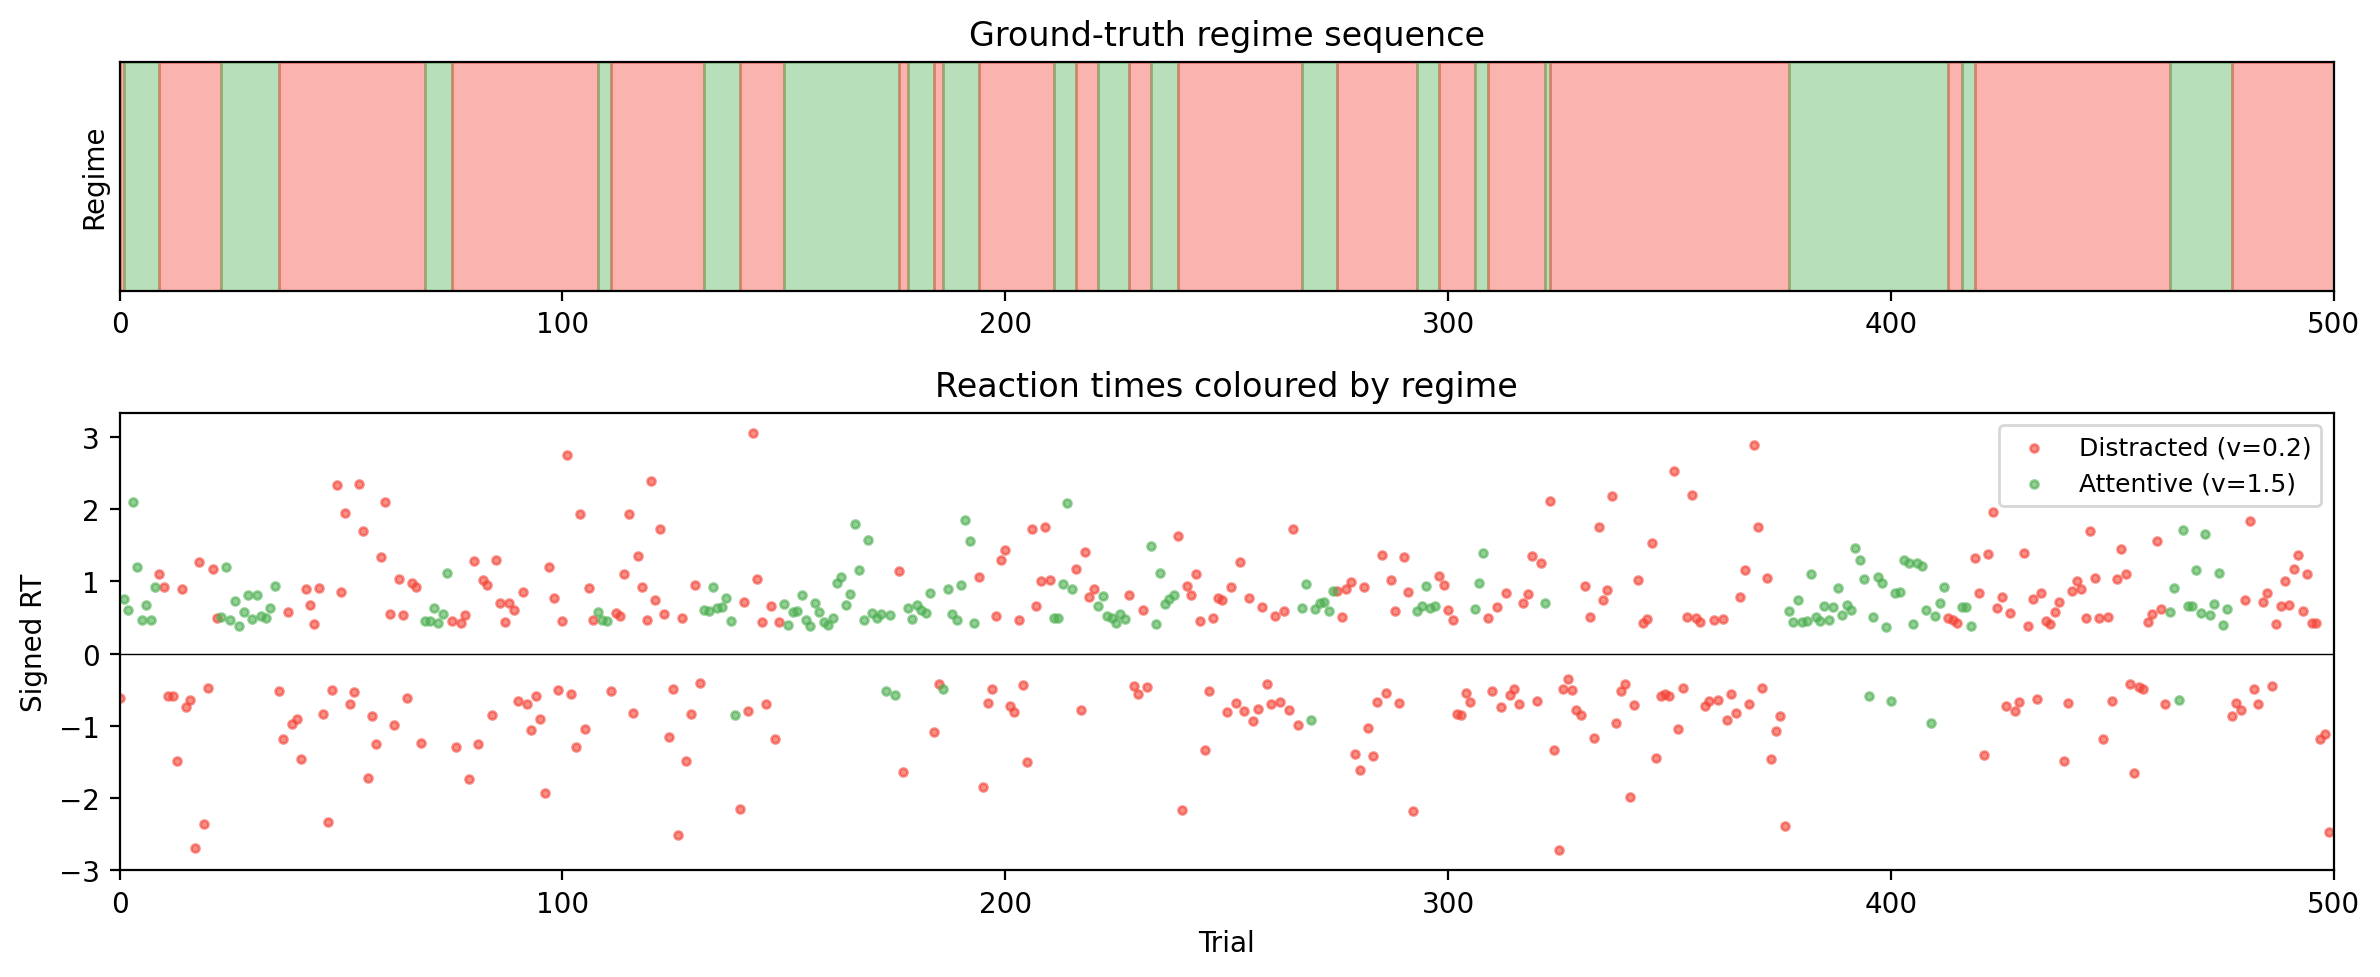

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), gridspec_kw={"height_ratios": [1, 2]})
colors = {0: "#F44336", 1: "#4CAF50"}  # red = distracted, green = attentive
labels = {0: "Distracted (v=0.2)", 1: "Attentive (v=1.5)"}
trials = np.arange(N_TRIALS)

ax = axes[0]
start = 0
for i in range(1, N_TRIALS + 1):
    if i == N_TRIALS or true_regimes[i] != true_regimes[start]:
        ax.axvspan(start, i, alpha=0.4, color=colors[true_regimes[start]])
        start = i
ax.set_xlim(0, N_TRIALS); ax.set_yticks([]); ax.set_ylabel("Regime")
ax.set_title("Ground-truth regime sequence")

ax = axes[1]
for k in (0, 1):
    m = true_regimes == k
    ax.scatter(trials[m], df["rt"].values[m] * df["response"].values[m],
               s=8, alpha=0.6, color=colors[k], label=labels[k])
ax.axhline(0, color="k", lw=0.5)
ax.set_xlim(0, N_TRIALS); ax.set_xlabel("Trial"); ax.set_ylabel("Signed RT")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Reaction times coloured by regime")
fig.tight_layout(); plt.show()

## Part 3: Build the model with `RSSSM`
---

The entire model is one constructor call. We pass:

- `model="ddm"` — the emission SSM (any HSSM-supported model works, analytical or LAN);
- `K=2` — the number of regimes;
- `switching_params=["v"]` — the drift rate is inferred *per regime* (a length-$K$ vector); every other parameter is shared;
- priors for each parameter, in the usual HSSM `{"name": ..., ...}` form.

`RSSSM` automatically marginalises the regimes out with the forward algorithm and adds an **`ordered` transform** to the anchor parameter (`v`) so that $v_0 < v_1$ — this breaks the label-switching symmetry (permuting regime labels leaves the likelihood unchanged, so without a constraint the posterior would be multi-modal). By convention **regime 0 is the low-drift regime**.

No participant column found; treating all rows as a single participant.
RSSSM model initialized successfully.


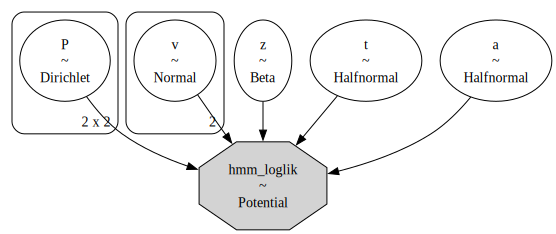

In [4]:
model = hssm.RSSSM(
    data=df,
    model="ddm",
    K=2,
    switching_params=["v"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)
model.graph()

### How the likelihood works

Under the hood `RSSSM` evaluates the **forward algorithm** in log-space, exactly as the hand-built tutorial does:

1. **Per-regime emission densities.** For every trial $t$ and regime $k$, evaluate $\log p(rt_t, \text{resp}_t \mid \theta_k)$ — the DDM log-density under that regime's parameters.
2. **Forward recursion.** Track $\log\alpha_t(k) = \log p(y_{1:t},\, s_t = k)$, updating it trial-by-trial by combining the previous trial's beliefs with the transition matrix $P$ and the current emission density.
3. **Marginal likelihood.** Summing over regimes at the final trial gives $\log p(y_{1:T})$ — the likelihood of the whole sequence over *all* possible regime paths.

This single scalar is contributed to the PyMC model as a `pm.Potential`, so NUTS only ever sees continuous parameters. (`RSSSM` uses a numerically-stable *normalised* forward recursion that keeps gradients finite even for long sessions.)

## Part 4: Fit and check the posterior
---

`RSSSM.sample()` defaults to the `numpyro` NUTS sampler — the forward `scan` JIT-compiles to `jax.lax.scan`, which is dramatically faster than the PyMC default on the batched recursion.

In [5]:
idata = model.sample(draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=42)

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:24<00:00, 82.16it/s, 15 steps of size 3.70e-01. acc. prob=0.93] 
/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,1000,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend runn

In [6]:
model.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.824,0.021,0.787,0.865,0.001,0.000,1008.0,1130.0,1.0
"P[0, 0]",0.917,0.034,0.851,0.972,0.001,0.001,1117.0,1075.0,1.0
"P[0, 1]",0.083,0.034,0.028,0.149,0.001,0.001,1117.0,1075.0,1.0
"P[1, 0]",0.143,0.042,0.068,0.221,0.001,0.001,1121.0,1380.0,1.0
"P[1, 1]",0.857,0.042,0.779,0.932,0.001,0.001,1121.0,1380.0,1.0
t,0.305,0.008,0.288,0.320,0.000,0.000,1204.0,1236.0,1.0
v[0],0.063,0.153,-0.206,0.351,0.005,0.004,1027.0,905.0,1.0
v[1],1.737,0.416,1.049,2.541,0.014,0.011,941.0,1050.0,1.0
z,0.508,0.017,0.476,0.539,0.000,0.000,1448.0,1483.0,1.0


The two drift rates are recovered, ordered ($v_0 < v_1$), and close to the true $[0.2, 1.5]$, alongside the shared $a$, $z$, $t$ and the transition matrix $P$. Let's compare posterior means to the ground truth directly:

In [7]:
post = idata.posterior
recovered = {
    "v[0] (distracted)": (float(post["v"].mean(("chain","draw"))[0]), V_TRUE[0]),
    "v[1] (attentive)":  (float(post["v"].mean(("chain","draw"))[1]), V_TRUE[1]),
    "a":  (float(post["a"].mean()), A_TRUE),
    "z":  (float(post["z"].mean()), Z_TRUE),
    "t":  (float(post["t"].mean()), T_TRUE),
}
pd.DataFrame(
    [(k, f"{est:.3f}", truth) for k, (est, truth) in recovered.items()],
    columns=["parameter", "posterior mean", "true value"],
)

,parameter,posterior mean,true value
0,v[0] (distracted),0.063,0.2
1,v[1] (attentive),1.737,1.5
2,a,0.824,0.8
3,z,0.508,0.5
4,t,0.305,0.3


Trace plots confirm the chains mix well and agree (no label-switching across chains):

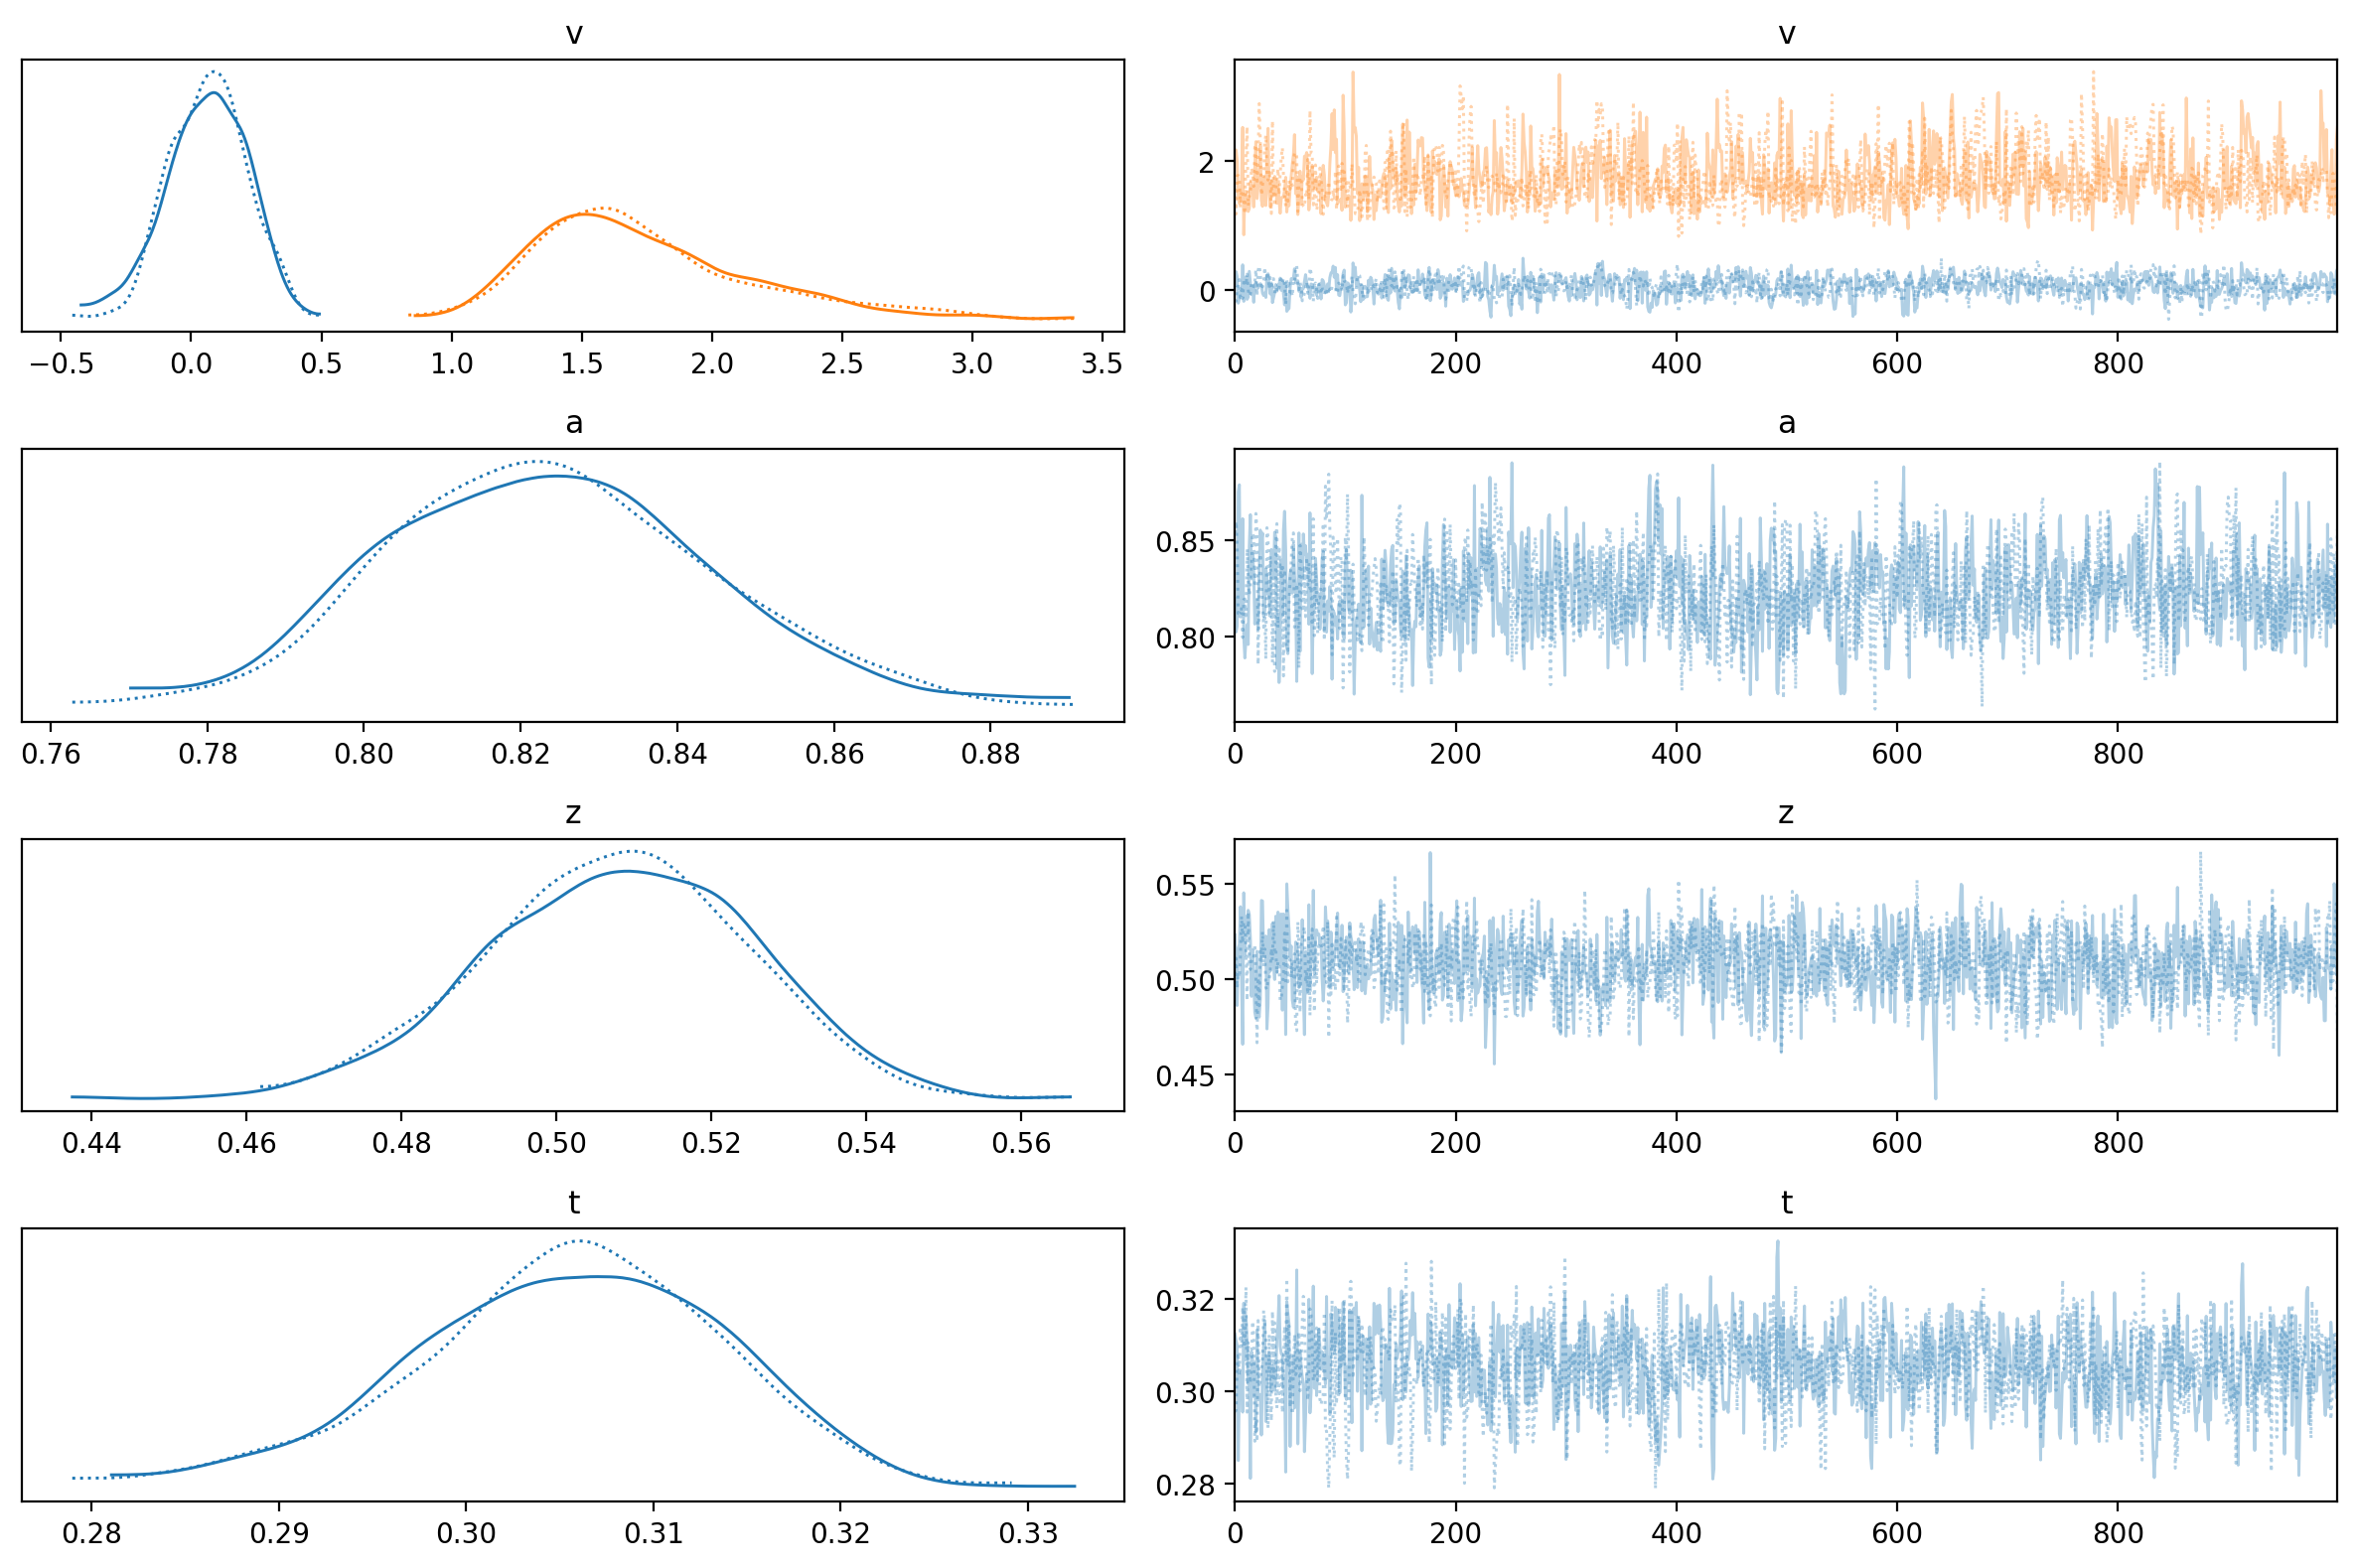

In [8]:
az.plot_trace(idata, var_names=["v", "a", "z", "t"], compact=True); plt.tight_layout()

A pair plot for the two drift rates and the boundary shows the posterior geometry and any trade-offs between parameters:

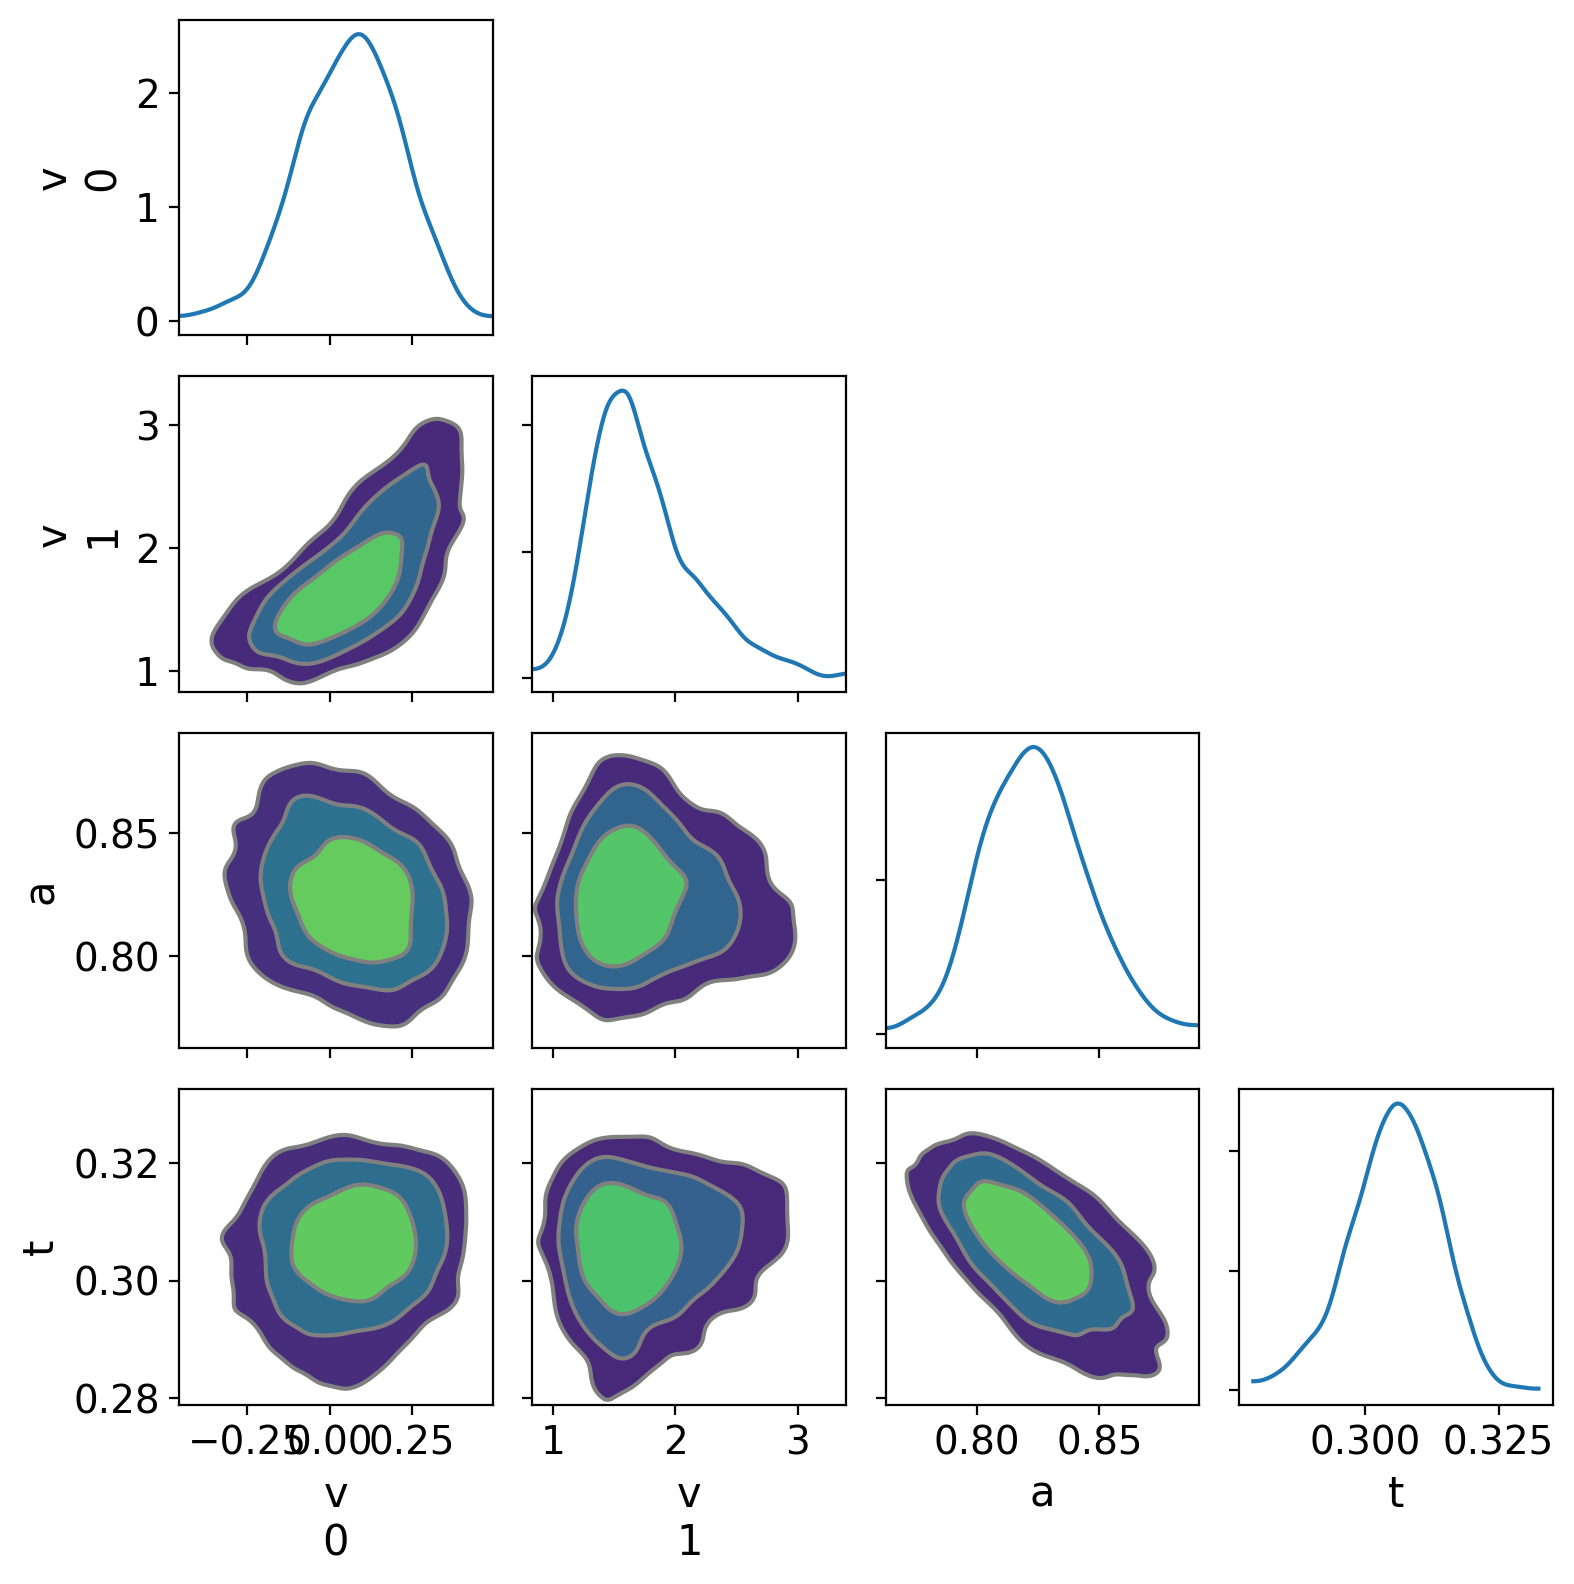

In [9]:
az.plot_pair(idata, var_names=["v", "a", "t"], kind="kde", marginals=True,
             figsize=(8, 8)); plt.tight_layout()

## Part 5: Recover the latent regimes (FFBS)
---

NUTS marginalised the regimes out, so the posterior holds $v, a, z, t, P$ — but **not** which regime was active on each trial. To recover them we use **Forward-Filter Backward-Sample (FFBS)**, run *post-hoc* for a set of posterior draws via `model.infer_regimes()`.

**Why two passes?** The forward filter alone gives $\alpha_t(k) = p(y_{1:t}, s_t=k)$ — a *filtering* distribution that only uses past data. Picking $\arg\max_k \alpha_t(k)$ independently per trial would ignore the Markov structure. The backward pass samples regimes in reverse, $s_t \sim p(s_t = k \mid s_{t+1}, y_{1:T}) \propto \alpha_t(k)\, P_{k,\,s_{t+1}}$, producing sequences that are **jointly consistent** with both the data and the chain dynamics. Repeating across posterior draws propagates parameter uncertainty into the regime estimates.

In [10]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)

`plot_regime_recovery` overlays the recovered posterior regime probability (stacked area) against the ground-truth regime sequence:

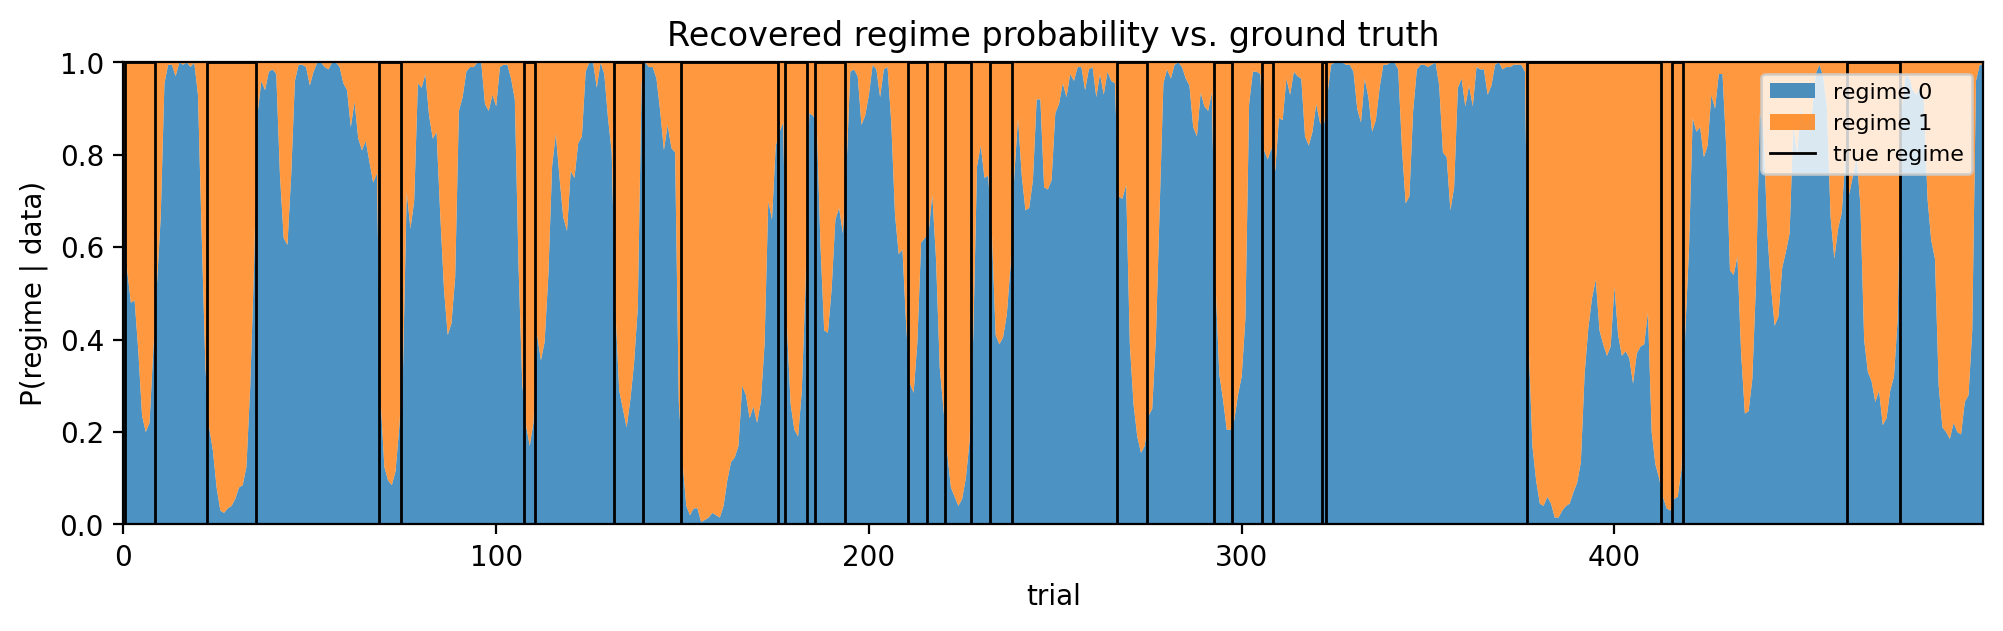

In [11]:
ax = model.plot_regime_recovery(regimes_idata, true_regimes=true_regimes)
ax.set_title("Recovered regime probability vs. ground truth");

We can quantify recovery: take the marginal-MAP regime per trial and compare to the truth.

In [12]:
freq = regimes_idata.posterior_regimes["regime_sample_frequency"].values[0]  # (T, K)
map_regime = freq.argmax(axis=1)
accuracy = (map_regime == true_regimes).mean()
print(f"Per-trial regime recovery accuracy: {accuracy:.1%}")

Per-trial regime recovery accuracy: 85.8%


## Part 6: Model comparison with LOO
---

Because the sampler contributes a single scalar marginal, the per-trial `log_likelihood` group that `arviz.loo` / `arviz.waic` need is reconstructed *post-hoc*. Pass `include_log_likelihood=True` to `sample()` (done here after the fact via `compute_log_likelihood`), then run `loo`. This lets you compare, say, a $K=2$ against a $K=1$ (no-switching) model, or different switching sets.

In [13]:
model.compute_log_likelihood(idata)
az.loo(idata)

Computed from 2000 posterior samples and 500 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -473.88    24.23
p_loo        7.99        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      500  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

## Part 7: Reaction times by regime
---

A useful sanity check: split the observed RTs by the *recovered* regime and confirm the two regimes have distinguishable RT distributions — the attentive regime should be faster and more accurate.

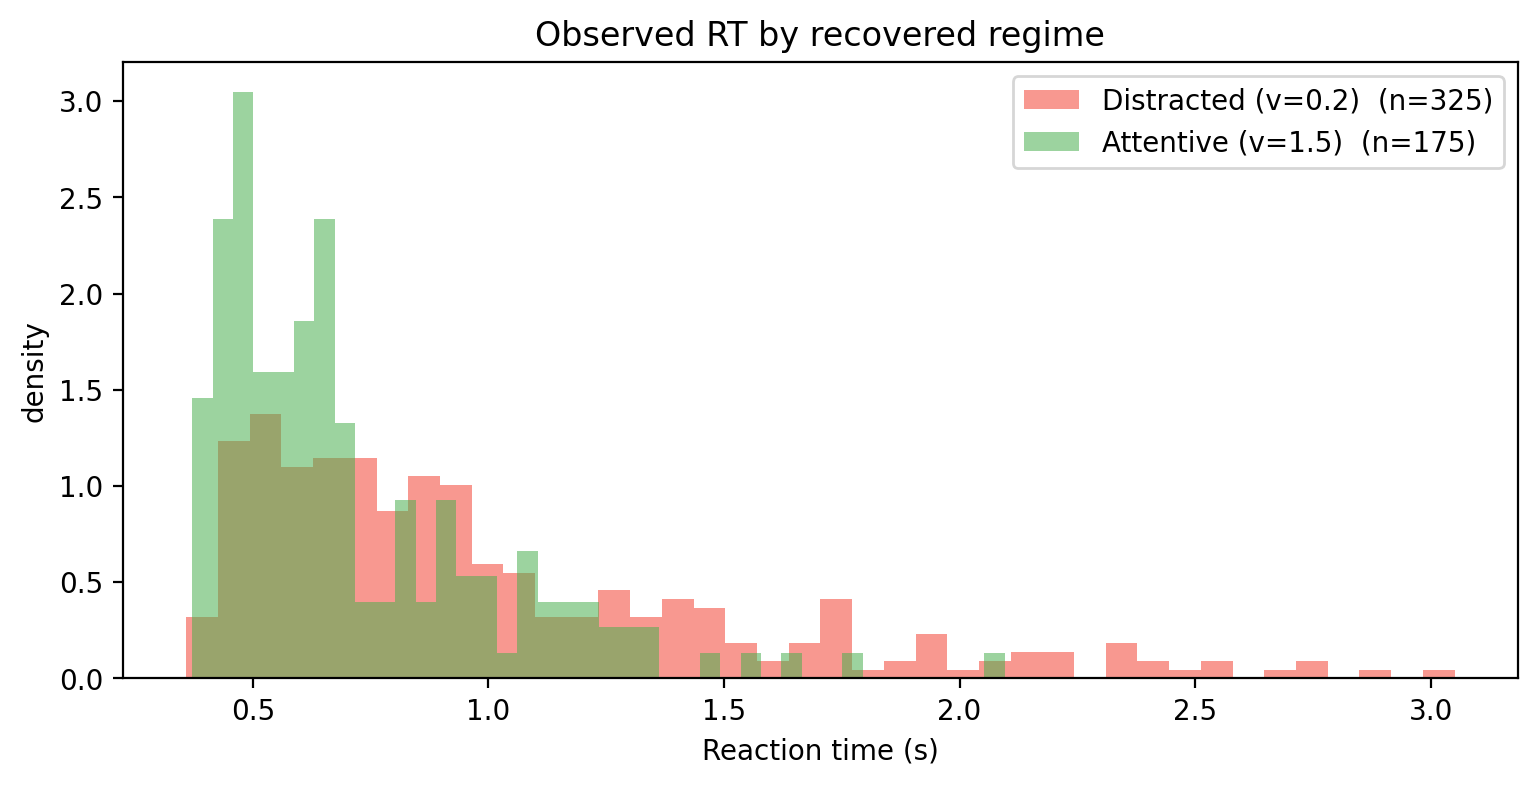

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for k in (0, 1):
    rt_k = df["rt"].values[map_regime == k]
    ax.hist(rt_k, bins=40, alpha=0.55, color=colors[k], density=True,
            label=f"{labels[k]}  (n={len(rt_k)})")
ax.set_xlabel("Reaction time (s)"); ax.set_ylabel("density")
ax.legend(); ax.set_title("Observed RT by recovered regime"); plt.show()

## Part 8: Summary and extensions
---

### What we did

- Built a regime-switching DDM in **a single `RSSSM(...)` call**, where the hand-written tutorial needed ~50 lines of PyMC: the forward algorithm, the `ordered`-transform anchor, and the FFBS routine are all handled for you.
- Fit it with NUTS (numpyro), recovered the drift rates / transition matrix, and confirmed clean mixing with no label-switching.
- Recovered the latent regime sequence post-hoc with `infer_regimes` (FFBS) and validated it against the ground truth.
- Reconstructed per-trial log-likelihoods for `arviz.loo` model comparison.

### Interpretation tips

- **Label switching.** The `ordered` transform makes permuted-label modes unreachable, so chains should be unimodal. If you ever disable it (`ordering="none"`), expect multi-modality.
- **Sticky transitions.** The default transition prior favours self-transitions — a sensible bias for cognitive data where regime switches are rare. Adjust it with `transition_prior` for your domain.
- **Number of regimes.** $K$ is fixed per fit; compare candidate $K$ with `loo`/`waic` (interpret with care — HMM observations are dependent).

### Where to go next

- **More participants and more regimes.** The companion tutorial [*Multi-participant regime-switching SSMs*](rsssm_multiparticipant.ipynb) scales to a panel of participants at $K=3$, with per-participant regime recovery and pooling options (`pooling="full"` / `"none"`).
- **More switching parameters.** Let the boundary `a` or non-decision time `t` switch too: `switching_params=["v", "a"]`.
- **Regime-specific lapses.** Add a per-regime lapse rate with `switching_params=[..., "p_outlier"]`, giving each regime its own $(1-p_k)\,\text{SSM}_k + p_k\,\text{lapse}$ mixture.
- **Any SSM.** Swap `model="ddm"` for `"angle"`, `"ddm_sdv"`, `"levy"`, … — analytical or LAN, the rest of the workflow is identical.